In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to your database and load all your games
conn = psycopg2.connect(
    dbname="omni_chess",
    user="sohampatel",
    host="localhost",
    port="5432"
)

query = """
    SELECT 
        g.id,
        g.white_username,
        g.black_username,
        g.winner,
        g.speed,
        g.opening_name,
        g.opening_eco,
        g.rated,
        g.created_at,
        g.status,
        pg.color
    FROM games g
    JOIN player_games pg ON g.id = pg.game_id
    JOIN players p ON pg.player_id = p.id
    WHERE p.username = 'sojam9090'
"""

df = pd.read_sql(query, conn)
conn.close()

print(f"Total games loaded: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Total games loaded: 19

Columns: ['id', 'white_username', 'black_username', 'winner', 'speed', 'opening_name', 'opening_eco', 'rated', 'created_at', 'status', 'color']

First 3 rows:


/var/folders/7c/_pc026n501j4gdz768y7lp4m0000gn/T/ipykernel_32291/1386822606.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,white_username,black_username,winner,speed,opening_name,opening_eco,rated,created_at,status,color
0,TYMOIJeA,kinglogan,sojam9090,white,blitz,Philidor Defense,C41,True,1775366962328,resign,black
1,2Zzb02IH,ODLINAV,sojam9090,black,blitz,Philidor Defense,C41,True,1775366582892,outoftime,black
2,FL1qwn7G,sojam9090,alex7551,white,blitz,Hungarian Opening,A00,True,1775366347936,mate,white


In [2]:
# Create a column: did sojam9090 win?
def did_i_win(row):
    if row['winner'] == 'draw':
        return 'draw'
    elif row['color'] == row['winner']:
        return 'win'
    else:
        return 'loss'

df['result'] = df.apply(did_i_win, axis=1)

# Overall win/loss/draw counts
print("=== YOUR OVERALL RECORD ===")
print(df['result'].value_counts())
print(f"\nWin rate: {round(len(df[df['result']=='win']) / len(df) * 100, 1)}%")

=== YOUR OVERALL RECORD ===
result
win     10
loss     8
draw     1
Name: count, dtype: int64

Win rate: 52.6%


=== WIN RATE BY COLOR ===
result  draw  loss  win
color                  
black      0     5    4
white      1     3    6


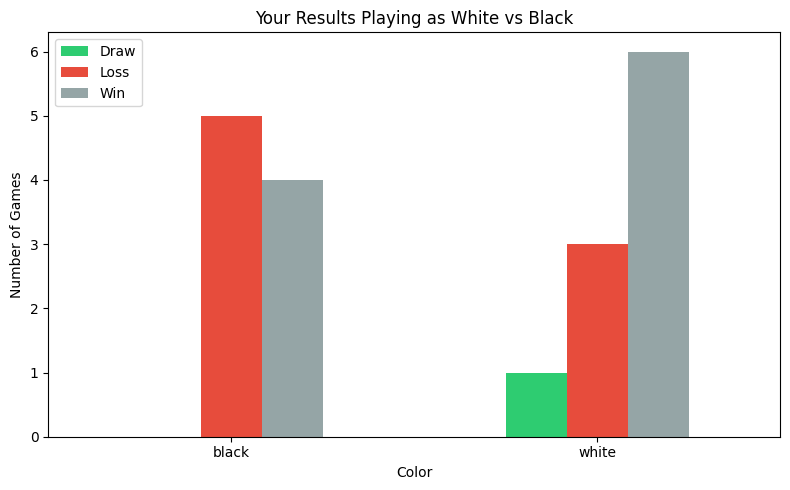

In [3]:
print("=== WIN RATE BY COLOR ===")
color_results = df.groupby(['color', 'result']).size().unstack(fill_value=0)
print(color_results)

color_results.plot(kind='bar', figsize=(8,5), color=['#2ecc71','#e74c3c','#95a5a6'])
plt.title('Your Results Playing as White vs Black')
plt.xlabel('Color')
plt.ylabel('Number of Games')
plt.xticks(rotation=0)
plt.legend(['Draw', 'Loss', 'Win'])
plt.tight_layout()
plt.show()

=== YOUR MOST PLAYED OPENINGS ===
opening_name
Philidor Defense                                3
Hungarian Opening: Slav Formation               2
Hungarian Opening                               1
Zukertort Opening: Queen's Gambit Invitation    1
Hungarian Opening: Reversed Modern Defense      1
Nimzo-Larsen Attack: Modern Variation           1
Grob Opening: Grob Gambit                       1
Hungarian Opening: Sicilian Invitation          1
Bishop's Opening                                1
Queen's Pawn Game: Levitsky Attack              1
Name: count, dtype: int64


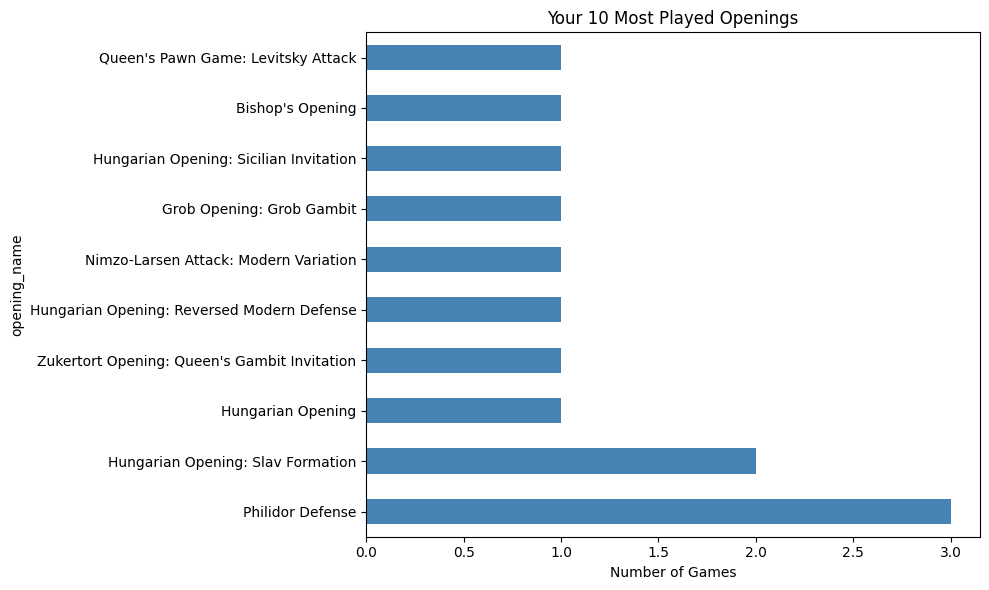

In [4]:
print("=== YOUR MOST PLAYED OPENINGS ===")
top_openings = df['opening_name'].value_counts().head(10)
print(top_openings)

top_openings.plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title('Your 10 Most Played Openings')
plt.xlabel('Number of Games')
plt.tight_layout()
plt.show()

In [5]:
print("=== WIN RATE BY OPENING ===")
opening_stats = df.groupby('opening_name')['result'].value_counts().unstack(fill_value=0)

# Add win rate column
if 'win' in opening_stats.columns:
    opening_stats['win_rate'] = round(
        opening_stats['win'] / opening_stats.sum(axis=1) * 100, 1
    )
    print(opening_stats.sort_values('win_rate', ascending=False))

=== WIN RATE BY OPENING ===
result                                        draw  loss  win  win_rate
opening_name                                                           
Grob Opening: Grob Gambit                        0     0    1     100.0
Hungarian Opening                                0     0    1     100.0
Hungarian Opening: Sicilian Invitation           0     0    1     100.0
King's Indian Attack, with e6                    0     0    1     100.0
King's Pawn Game: Napoleon Attack                0     0    1     100.0
Nimzo-Larsen Attack: Modern Variation            0     0    1     100.0
Queen's Gambit Declined                          0     0    1     100.0
Zukertort Opening: Queen's Gambit Invitation     0     0    1     100.0
Hungarian Opening: Slav Formation                0     1    1      50.0
Philidor Defense                                 0     2    1      33.3
Bishop's Opening                                 0     1    0       0.0
Hungarian Opening: Indian Defense   

=== HOW DO YOUR GAMES END? ===
status
resign       7
outoftime    6
mate         5
draw         1
Name: count, dtype: int64


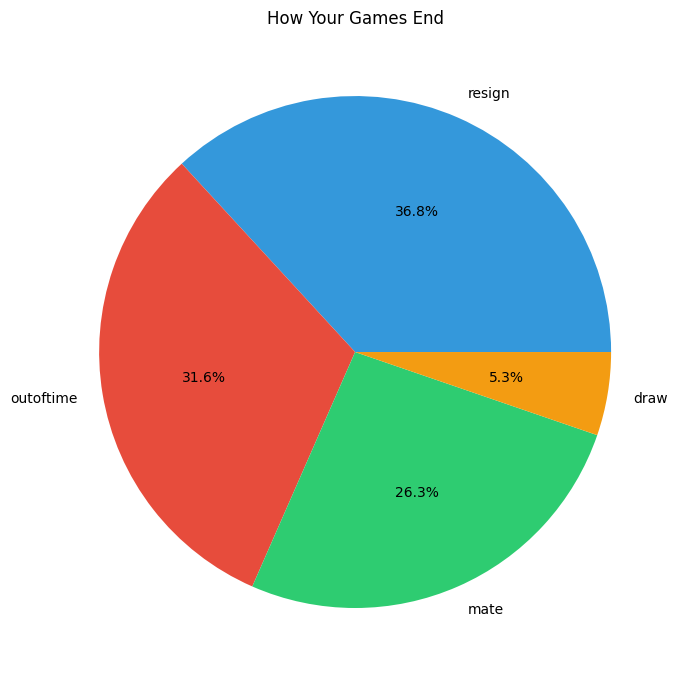

In [6]:
print("=== HOW DO YOUR GAMES END? ===")
status_counts = df['status'].value_counts()
print(status_counts)

plt.figure(figsize=(7,7))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', 
        colors=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'])
plt.title('How Your Games End')
plt.tight_layout()
plt.show()

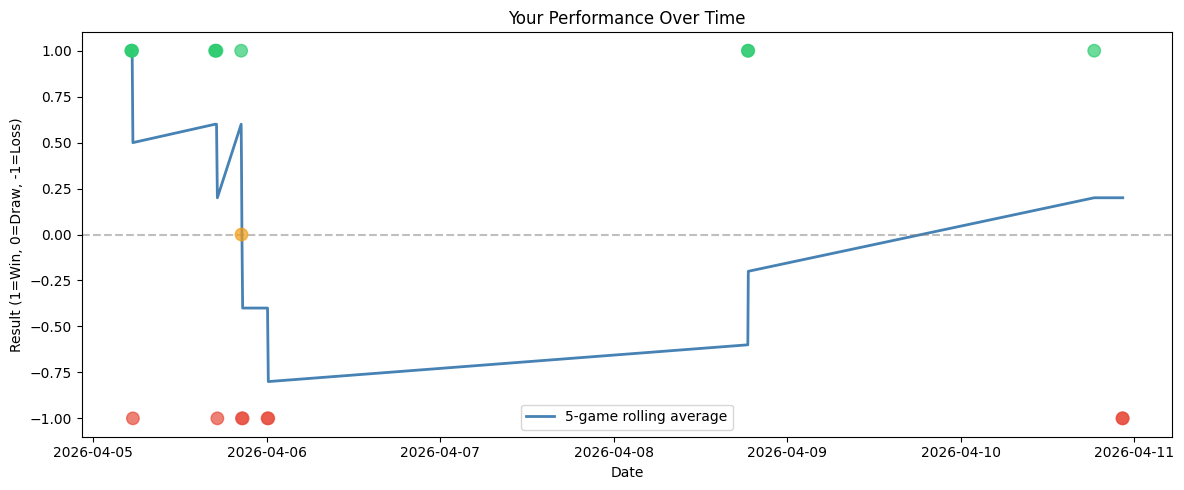

In [7]:
# Convert timestamp to readable date
df['date'] = pd.to_datetime(df['created_at'], unit='ms')
df = df.sort_values('date')

# Assign numbers to results for plotting
df['result_num'] = df['result'].map({'win': 1, 'draw': 0, 'loss': -1})

# Rolling average over last 5 games
df['rolling_avg'] = df['result_num'].rolling(window=5, min_periods=1).mean()

plt.figure(figsize=(12,5))
colors = df['result'].map({'win':'#2ecc71', 'draw':'#f39c12', 'loss':'#e74c3c'})
plt.scatter(df['date'], df['result_num'], c=colors, alpha=0.7, s=80, zorder=3)
plt.plot(df['date'], df['rolling_avg'], color='steelblue', linewidth=2, label='5-game rolling average')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Your Performance Over Time')
plt.ylabel('Result (1=Win, 0=Draw, -1=Loss)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
print("=== YOUR COMPLETE CHESS PROFILE ===")
print(f"Total games played:  {len(df)}")
print(f"Wins:                {len(df[df['result']=='win'])}")
print(f"Losses:              {len(df[df['result']=='loss'])}")
print(f"Draws:               {len(df[df['result']=='draw'])}")
print(f"Overall win rate:    {round(len(df[df['result']=='win'])/len(df)*100,1)}%")
print(f"Most played opening: {df['opening_name'].value_counts().index[0]}")
print(f"Favorite color:      {df['color'].value_counts().index[0]}")
print(f"Most common speed:   {df['speed'].value_counts().index[0]}")
print(f"Date range:          {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")

=== YOUR COMPLETE CHESS PROFILE ===
Total games played:  19
Wins:                10
Losses:              8
Draws:               1
Overall win rate:    52.6%
Most played opening: Philidor Defense
Favorite color:      white
Most common speed:   blitz
Date range:          2026-04-05 to 2026-04-10


In [9]:
import sys
sys.path.append('/Users/sohampatel/Desktop/omni-chess')
from pipeline import run_pipeline

# Pull smaller batches from multiple players instead
run_pipeline("fabianocaruana", max_games=20)
run_pipeline("hikaru", max_games=20)
run_pipeline("magnus", max_games=20)
print("Done! Added 60 games from top players.")


Starting pipeline for: fabianocaruana
Player ID in database: 4


/Users/sohampatel/Desktop/omni-chess/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Fetched 1 games for fabianocaruana
Fetched 1 games from Lichess


NotNullViolation: null value in column "id" of relation "games" violates not-null constraint
DETAIL:  Failing row contains (null, unknown, unknown, draw, null, null, null, null, null, null, null).


In [10]:
# Fixed pipeline that skips games with missing data
import psycopg2
import sys
sys.path.append('/Users/sohampatel/Desktop/omni-chess')
from lichess_api import fetch_games
from db import insert_player, insert_game, insert_player_game

def run_pipeline_safe(username, max_games=20):
    print(f"Starting pipeline for: {username}")
    player_id = insert_player(username)
    games = fetch_games(username, max_games=max_games)
    print(f"Fetched {len(games)} games")
    
    saved = 0
    skipped = 0
    for game in games:
        # Skip any game missing an ID
        if not game.get("id"):
            skipped += 1
            continue
        try:
            insert_game(game)
            players = game.get("players", {})
            white = players.get("white", {}).get("user", {}).get("name", "")
            color = "white" if white.lower() == username.lower() else "black"
            insert_player_game(player_id, game["id"], color)
            saved += 1
        except Exception as e:
            skipped += 1
            continue
    
    print(f"Saved {saved} games, skipped {skipped}")

run_pipeline_safe("fabianocaruana", max_games=20)
run_pipeline_safe("hikaru", max_games=20)
print("All done!")

Starting pipeline for: fabianocaruana
Fetched 1 games for fabianocaruana
Fetched 1 games
Saved 0 games, skipped 1
Starting pipeline for: hikaru
Fetched 1 games for hikaru
Fetched 1 games
Saved 0 games, skipped 1
All done!


In [11]:
# Correct Lichess usernames for top players
run_pipeline_safe("RebeccaHarris", max_games=20)
run_pipeline_safe("Zhigalko_Sergei", max_games=20)
run_pipeline_safe("penguingim1", max_games=20)
print("All done!")

Starting pipeline for: RebeccaHarris
Fetched 20 games for RebeccaHarris
Fetched 20 games
Saved 20 games, skipped 0
Starting pipeline for: Zhigalko_Sergei
Fetched 20 games for Zhigalko_Sergei
Fetched 20 games
Saved 20 games, skipped 0
Starting pipeline for: penguingim1
Fetched 20 games for penguingim1
Fetched 20 games
Saved 20 games, skipped 0
All done!


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import pandas as pd
import psycopg2

# Reload your games
conn = psycopg2.connect(
    dbname="omni_chess",
    user="sohampatel",
    host="localhost",
    port="5432"
)

df = pd.read_sql("""
    SELECT g.speed, g.opening_eco, g.opening_name,
           pg.color, g.winner
    FROM games g
    JOIN player_games pg ON g.id = pg.game_id
    JOIN players p ON pg.player_id = p.id
    WHERE p.username = 'sojam9090'
""", conn)
conn.close()

# Create target: did YOU win?
def did_i_win(row):
    if row['winner'] == 'draw':
        return 'draw'
    elif row['color'] == row['winner']:
        return 'win'
    else:
        return 'loss'

df['result'] = df.apply(did_i_win, axis=1)

# Encode features into numbers for ML
le_speed = LabelEncoder()
le_color = LabelEncoder()
le_eco = LabelEncoder()

df['speed_enc'] = le_speed.fit_transform(df['speed'].fillna('unknown'))
df['color_enc'] = le_color.fit_transform(df['color'].fillna('unknown'))
df['eco_enc'] = le_eco.fit_transform(df['opening_eco'].fillna('unknown'))

# Features and target
X = df[['speed_enc', 'color_enc', 'eco_enc']]
y = df['result']

print(f"Dataset size: {len(df)} games")
print(f"Features: {list(X.columns)}")
print(f"Target distribution:\n{y.value_counts()}")

Dataset size: 19 games
Features: ['speed_enc', 'color_enc', 'eco_enc']
Target distribution:
result
win     10
loss     8
draw     1
Name: count, dtype: int64


/var/folders/7c/_pc026n501j4gdz768y7lp4m0000gn/T/ipykernel_32291/2897443416.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


In [13]:
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn'], capture_output=True)
print("Installed!")

Installed!


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import pandas as pd
import psycopg2

# Reload your games
conn = psycopg2.connect(
    dbname="omni_chess",
    user="sohampatel",
    host="localhost",
    port="5432"
)

df = pd.read_sql("""
    SELECT g.speed, g.opening_eco, g.opening_name,
           pg.color, g.winner
    FROM games g
    JOIN player_games pg ON g.id = pg.game_id
    JOIN players p ON pg.player_id = p.id
    WHERE p.username = 'sojam9090'
""", conn)
conn.close()

# Create target: did YOU win?
def did_i_win(row):
    if row['winner'] == 'draw':
        return 'draw'
    elif row['color'] == row['winner']:
        return 'win'
    else:
        return 'loss'

df['result'] = df.apply(did_i_win, axis=1)

# Encode features into numbers for ML
le_speed = LabelEncoder()
le_color = LabelEncoder()
le_eco = LabelEncoder()

df['speed_enc'] = le_speed.fit_transform(df['speed'].fillna('unknown'))
df['color_enc'] = le_color.fit_transform(df['color'].fillna('unknown'))
df['eco_enc'] = le_eco.fit_transform(df['opening_eco'].fillna('unknown'))

# Features and target
X = df[['speed_enc', 'color_enc', 'eco_enc']]
y = df['result']

print(f"Dataset size: {len(df)} games")
print(f"Features: {list(X.columns)}")
print(f"Target distribution:\n{y.value_counts()}")

Dataset size: 19 games
Features: ['speed_enc', 'color_enc', 'eco_enc']
Target distribution:
result
win     10
loss     8
draw     1
Name: count, dtype: int64


/var/folders/7c/_pc026n501j4gdz768y7lp4m0000gn/T/ipykernel_32291/2897443416.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Train your first Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Use cross validation since we have a small dataset
scores = cross_val_score(model, X, y, cv=3, scoring='accuracy')

print("=== YOUR FIRST MACHINE LEARNING MODEL ===")
print(f"Model type: Random Forest Classifier")
print(f"Features used: game speed, color (white/black), opening")
print(f"Accuracy scores: {[round(s,2) for s in scores]}")
print(f"Average accuracy: {round(scores.mean()*100, 1)}%")

# Train on all data to get feature importance
model.fit(X, y)

print(f"\n=== FEATURE IMPORTANCE ===")
features = ['Game Speed', 'Color (White/Black)', 'Opening Choice']
for feat, imp in zip(features, model.feature_importances_):
    bar = '█' * int(imp * 30)
    print(f"{feat:<20} {bar} {round(imp*100,1)}%")

print("\nThis tells you which factors matter most in predicting your wins!")

/Users/sohampatel/Desktop/omni-chess/venv/lib/python3.9/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


=== YOUR FIRST MACHINE LEARNING MODEL ===
Model type: Random Forest Classifier
Features used: game speed, color (white/black), opening
Accuracy scores: [np.float64(0.43), np.float64(0.17), np.float64(0.5)]
Average accuracy: 36.5%

=== FEATURE IMPORTANCE ===
Game Speed            0.0%
Color (White/Black)  ███ 12.7%
Opening Choice       ██████████████████████████ 87.3%

This tells you which factors matter most in predicting your wins!


In [16]:
import pickle
import numpy as np

# Save the model first
with open('chess_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('encoders.pkl', 'wb') as f:
    pickle.dump({'speed': le_speed, 'color': le_color, 'eco': le_eco}, f)

print("Model saved!")

# Build a prediction function
def predict_win_chance(opening_eco, color, speed):
    """
    Given an opening ECO code, color, and speed
    predict your chances of winning.
    Example: predict_win_chance('C41', 'white', 'blitz')
    """
    try:
        speed_enc = le_speed.transform([speed])[0]
        color_enc = le_color.transform([color])[0]
        eco_enc = le_eco.transform([opening_eco])[0]
    except:
        print(f"Unknown value — try different inputs")
        return

    features = np.array([[speed_enc, color_enc, eco_enc]])
    probabilities = model.predict_proba(features)[0]
    classes = model.classes_

    print(f"\n=== WIN PREDICTION ===")
    print(f"Opening: {opening_eco} | Color: {color} | Speed: {speed}")
    print()
    for cls, prob in zip(classes, probabilities):
        bar = '█' * int(prob * 20)
        print(f"{cls:<6} {bar} {round(prob*100, 1)}%")

# Test it with your most common openings
print("Your Philidor Defense (C41) as black in blitz:")
predict_win_chance('C41', 'black', 'blitz')

print("\nYour Hungarian Opening (A00) as white in blitz:")
predict_win_chance('A00', 'white', 'blitz')

Model saved!
Your Philidor Defense (C41) as black in blitz:

=== WIN PREDICTION ===
Opening: C41 | Color: black | Speed: blitz

draw    0.0%
loss   ██████████████ 73.1%
win    █████ 26.9%

Your Hungarian Opening (A00) as white in blitz:

=== WIN PREDICTION ===
Opening: A00 | Color: white | Speed: blitz

draw   ██ 12.5%
loss   ███████ 36.4%
win    ██████████ 51.1%


/Users/sohampatel/Desktop/omni-chess/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/sohampatel/Desktop/omni-chess/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
